# Etapa 3 — Construcción de Grafos de Proximidad

Para cada instancia `.dat` que tenga un frente de Pareto limpio disponible:
1. Parsea el `.dat` → coordenadas, flags, probabilidades, R
2. Construye aristas con KD-tree (dist ≤ R)
3. Calcula el degree de cada nodo
4. Arma features: `[flag, prob, degree]` (sin coordenadas, por invarianza de escala)
5. Carga metadata del frente limpio (`cov_max`, `n_candidates`)
6. Guarda como objeto PyTorch Geometric `Data`

In [2]:
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.spatial import cKDTree
from pathlib import Path
import re
import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENTS_DIR = Path('../experiments')
CLEAN_DIR       = Path('../frentes_pareto_resultados/clean')
GRAPHS_DIR      = Path('../graphs')
GRAPHS_DIR.mkdir(exist_ok=True)

DATASETS = {
    #'phub'      : (EXPERIMENTS_DIR / 'phub',       CLEAN_DIR / 'phub'),
    'clustering': (EXPERIMENTS_DIR / 'clustering',  CLEAN_DIR / 'clustering'),
    #'cdmx'      : (EXPERIMENTS_DIR / 'cdmx',        CLEAN_DIR / 'cdmx'),
}

print('✓ Paths configurados')
for name, (exp, cln) in DATASETS.items():
    n_exp = len(list(exp.glob('*.dat')))
    n_cln = len([d for d in cln.iterdir() if d.is_dir()]) if cln.exists() else 0
    print(f'  {name:<12} experimentos={n_exp:>4}  frentes_limpios={n_cln:>4}')

✓ Paths configurados
  clustering   experimentos=   9  frentes_limpios=   9


## 1. Parser de archivos `.dat`

In [3]:
def parse_dat(filepath):
    """
    Lee un archivo .dat de AMPL y extrae los parámetros del problema.

    Devuelve:
      meta   : dict con N_total, P, R, nombre
      coords : np.ndarray (N, 2)  — coordenadas (x, y)
      flags  : np.ndarray (N,)    — 1=preinstalada, 0=candidata
      probs  : np.ndarray (N,)    — probabilidad de evento (0.0 si flag=1)
    """
    text = Path(filepath).read_text(encoding='utf-8', errors='replace')

    # Parámetros escalares
    N = int(re.search(r'param\s+N_total\s*:=\s*([\d]+)', text).group(1))
    P = float(re.search(r'param\s+P\s*:=\s*([\d.]+)', text).group(1))
    R = float(re.search(r'param\s+R\s*:=\s*([\d.eE+\-]+)', text).group(1))
    nombre = re.search(r'param\s+nombre_instancia\s*:=\s*"([^"]+)"', text).group(1)

    # Bloque de datos: todo entre ':=' y ';' del param coordx...
    block_match = re.search(
        r'param\s*:\s*coordx\s+coordy\s+flag\s+prob_ohca\s*:=(.+?);',
        text, re.DOTALL
    )
    block = block_match.group(1).strip()

    coords = np.empty((N, 2), dtype=np.float64)
    flags  = np.empty(N,      dtype=np.float32)
    probs  = np.empty(N,      dtype=np.float32)

    for line in block.splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        idx          = int(parts[0]) - 1   # 1-indexed → 0-indexed
        coords[idx]  = [float(parts[1]), float(parts[2])]
        flags[idx]   = float(parts[3])
        probs[idx]   = float(parts[4])

    meta = {'N': N, 'P': P, 'R': R, 'nombre': nombre}
    return meta, coords, flags, probs


# Prueba rápida
test_dat = EXPERIMENTS_DIR / 'phub' / 'wsc_0_R0p1455_pre13.dat'
meta, coords, flags, probs = parse_dat(test_dat)
print(f'N={meta["N"]}  P={meta["P"]}  R={meta["R"]:.4f}')
print(f'Preinstaladas : {int(flags.sum())}  |  Candidatas: {int((flags==0).sum())}')
print(f'coords shape  : {coords.shape}  rango x=[{coords[:,0].min():.3f},{coords[:,0].max():.3f}]')
print(f'probs range   : [{probs.min():.4f}, {probs.max():.4f}]')

N=150  P=137.0  R=0.1455
Preinstaladas : 13  |  Candidatas: 137
coords shape  : (150, 2)  rango x=[0.002,0.997]
probs range   : [0.0000, 0.8753]


## 2. Constructor de grafo

In [4]:
def build_graph(dat_path, clean_pareto_dir, instance_name):
    """
    Construye el grafo de proximidad para una instancia.

    Node features (3 por nodo):
      [flag, prob, degree]   — sin coordenadas (invarianza de escala)

    Atributos extras en Data:
      .instance_name  : str
      .R              : float  — radio de cobertura
      .n_candidates   : int    — nodos con flag=0
      .n_preinstalled : int    — nodos con flag=1
      .cov_max        : float  — máxima cobertura del frente de referencia
      .n_pareto       : int    — tamaño del frente de referencia
    """
    # 1. Parsear .dat
    meta, coords, flags, probs = parse_dat(dat_path)
    N = meta['N']
    R = meta['R']

    # 2. Aristas via KD-tree (evita O(N²) para instancias grandes)
    tree  = cKDTree(coords)
    pairs = tree.query_pairs(R, output_type='ndarray')  # shape (E, 2)

    if len(pairs) > 0:
        src = pairs[:, 0].astype(np.int64)
        dst = pairs[:, 1].astype(np.int64)
        # Bidireccional
        edge_index = torch.tensor(
            np.stack([np.concatenate([src, dst]),
                      np.concatenate([dst, src])]),
            dtype=torch.long
        )
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    # 3. Degree de cada nodo
    if edge_index.shape[1] > 0:
        degree = np.bincount(edge_index[0].numpy(), minlength=N).astype(np.float32)
    else:
        degree = np.zeros(N, dtype=np.float32)

    # 4. Node features: [flag, prob, degree]
    x = torch.tensor(
        np.stack([flags, probs, degree], axis=1),
        dtype=torch.float32
    )

    # 5. Metadata del frente de Pareto limpio
    obj = np.load(clean_pareto_dir / 'objectives.npy')  # (n_pareto, 2)
    cov_max = float(-obj[:, 0].min())   # f1 más negativo → mayor cobertura
    n_pareto = len(obj)

    # 6. Construir objeto Data
    data = Data(
        x          = x,
        edge_index = edge_index,
        num_nodes  = N,
    )
    data.instance_name  = instance_name
    data.R              = float(R)
    data.n_candidates   = int((flags == 0).sum())
    data.n_preinstalled = int(flags.sum())
    data.cov_max        = cov_max
    data.n_pareto       = n_pareto

    return data


# Prueba
test_clean = CLEAN_DIR / 'phub' / 'wsc_0_R0p1455_pre13'
g = build_graph(test_dat, test_clean, 'wsc_0_R0p1455_pre13')
print(g)
print(f'\nFeatures (primeros 3 nodos):')
print('  [flag, prob, degree]')
for i in range(3):
    print(f'  nodo {i}: {g.x[i].tolist()}')
print(f'\nn_candidates   : {g.n_candidates}')
print(f'n_preinstalled : {g.n_preinstalled}')
print(f'cov_max        : {g.cov_max:.4f}')
print(f'n_pareto       : {g.n_pareto}')
print(f'Aristas        : {g.edge_index.shape[1] // 2} (sin doble contar)')

Data(x=[150, 3], edge_index=[2, 1382], num_nodes=150, instance_name='wsc_0_R0p1455_pre13', R=0.14554425309821817, n_candidates=137, n_preinstalled=13, cov_max=24.8638, n_pareto=13)

Features (primeros 3 nodos):
  [flag, prob, degree]
  nodo 0: [0.0, 0.32010000944137573, 11.0]
  nodo 1: [0.0, 0.031599998474121094, 5.0]
  nodo 2: [1.0, 0.0, 6.0]

n_candidates   : 137
n_preinstalled : 13
cov_max        : 24.8638
n_pareto       : 13
Aristas        : 691 (sin doble contar)


## 3. Procesamiento completo

In [5]:
stats_records = []
skipped = []

for ds_name, (exp_dir, clean_dir) in DATASETS.items():
    out_dir = GRAPHS_DIR / ds_name
    out_dir.mkdir(exist_ok=True)

    dat_files = sorted(exp_dir.glob('*.dat'))
    print(f'\n── {ds_name.upper()} ({len(dat_files)} archivos .dat) ──')

    for dat_file in dat_files:
        inst_name = dat_file.stem
        pareto_dir = clean_dir / inst_name

        # Solo procesar instancias que tienen frente de Pareto limpio
        if not (pareto_dir / 'objectives.npy').exists():
            skipped.append(f'{ds_name}/{inst_name}')
            continue

        graph = build_graph(dat_file, pareto_dir, inst_name)

        # Guardar
        torch.save(graph, out_dir / f'{inst_name}.pt')

        n_edges = graph.edge_index.shape[1] // 2
        deg = graph.x[:, 2].numpy()

        stats_records.append({
            'dataset'       : ds_name,
            'instance'      : inst_name,
            'N'             : graph.num_nodes,
            'n_candidates'  : graph.n_candidates,
            'n_preinstalled': graph.n_preinstalled,
            'n_edges'       : n_edges,
            'deg_mean'      : round(float(deg.mean()), 2),
            'deg_max'       : int(deg.max()),
            'cov_max'       : round(graph.cov_max, 4),
            'n_pareto'      : graph.n_pareto,
            'R'             : graph.R,
        })

        print(f'  ✓ {inst_name:<45}  N={graph.num_nodes:>6}  '
              f'aristas={n_edges:>7}  deg_mean={deg.mean():.1f}  '
              f'pareto={graph.n_pareto}')

print(f'\n✓ Grafos guardados en graphs/')
if skipped:
    print(f'  Saltados (sin frente limpio): {len(skipped)}')


── CLUSTERING (9 archivos .dat) ──
  ✓ a1_R1800_pre28                                 N=  3000  aristas=  73265  deg_mean=48.8  pareto=46
  ✓ a2_R2400_pre9                                  N=  5250  aristas= 208660  deg_mean=79.5  pareto=42
  ✓ a3_R3050_pre10                                 N=  7500  aristas= 405214  deg_mean=108.1  pareto=45
  ✓ dim2_R5150_pre6                                N=  1351  aristas=  12302  deg_mean=18.2  pareto=67
  ✓ s1_R28000_pre9                                 N=  5000  aristas= 225029  deg_mean=90.0  pareto=64
  ✓ s2_R34000_pre28                                N=  5000  aristas= 231399  deg_mean=92.6  pareto=49
  ✓ s3_R35000_pre35                                N=  5000  aristas= 192388  deg_mean=77.0  pareto=50
  ✓ s4_R32000_pre47                                N=  5000  aristas= 203836  deg_mean=81.5  pareto=53
  ✓ unbalance_R1450_pre40                          N=  6500  aristas= 315909  deg_mean=97.2  pareto=101

✓ Grafos guardados en graphs/


## 4. Tabla resumen y estadísticas

In [6]:
df = pd.DataFrame(stats_records)
print(df.to_string(index=False))

print('\n── Resumen por dataset ──')
print(df.groupby('dataset')[['N','n_candidates','n_edges','deg_mean','n_pareto']]
        .agg(['min','max','mean'])
        .round(1)
        .to_string())

   dataset              instance    N  n_candidates  n_preinstalled  n_edges  deg_mean  deg_max   cov_max  n_pareto       R
clustering        a1_R1800_pre28 3000          2972              28    73265     48.84       93  487.7838        46  1800.0
clustering         a2_R2400_pre9 5250          5241               9   208660     79.49      125  880.6266        42  2400.0
clustering        a3_R3050_pre10 7500          7490              10   405214    108.06      157 1242.4749        45  3050.0
clustering       dim2_R5150_pre6 1351          1345               6    12302     18.21       45  204.4562        67  5150.0
clustering        s1_R28000_pre9 5000          4991               9   225029     90.01      234  817.6872        64 28000.0
clustering       s2_R34000_pre28 5000          4972              28   231399     92.56      248  837.8506        49 34000.0
clustering       s3_R35000_pre35 5000          4965              35   192388     76.96      290  853.1122        50 35000.0
clusteri

## 5. Verificación visual — una instancia por dataset

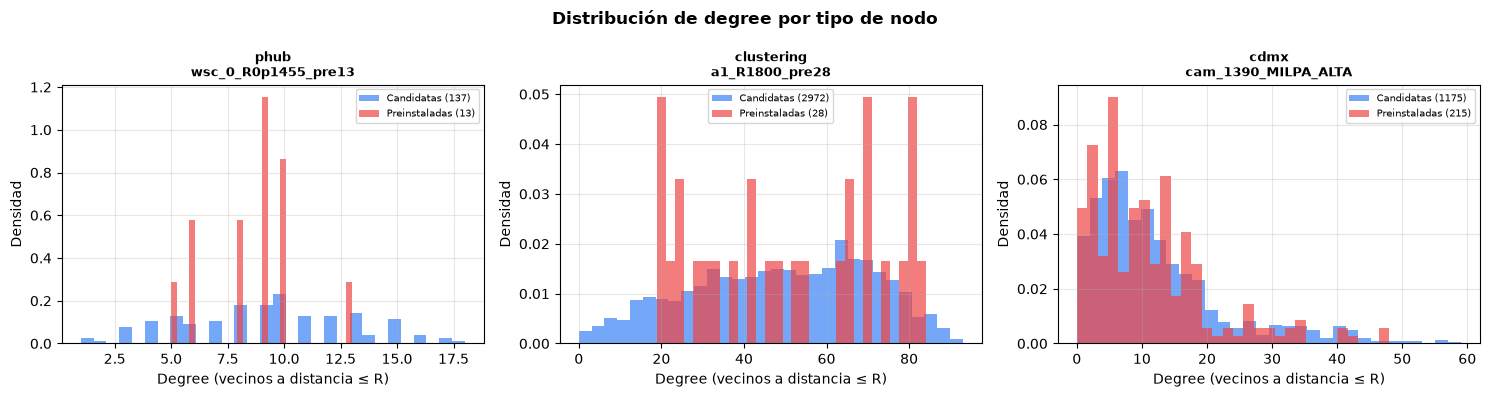

✓ Imagen guardada


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

examples = {
    'phub'      : 'wsc_0_R0p1455_pre13',
    'clustering': 'a1_R1800_pre28',
    'cdmx'      : 'cam_1390_MILPA_ALTA',
}

for ax, (ds_name, inst_name) in zip(axes, examples.items()):
    pt_file = GRAPHS_DIR / ds_name / f'{inst_name}.pt'
    if not pt_file.exists():
        ax.set_title(f'{ds_name}\n(no procesado)', color='red')
        continue

    g = torch.load(pt_file, weights_only=False)
    flags  = g.x[:, 0].numpy()
    probs  = g.x[:, 1].numpy()
    degree = g.x[:, 2].numpy()

    # Histograma de degree
    ax.hist(degree[flags == 0], bins=30, color='#3B82F6', alpha=0.7,
            label=f'Candidatas ({int((flags==0).sum())})', density=True)
    ax.hist(degree[flags == 1], bins=30, color='#EF4444', alpha=0.7,
            label=f'Preinstaladas ({int(flags.sum())})', density=True)
    ax.set_title(f'{ds_name}\n{inst_name[:30]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Degree (vecinos a distancia ≤ R)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribución de degree por tipo de nodo', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/graph_degree_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ Imagen guardada')

## 6. Verificación de carga y consistencia

In [8]:
# Cargar un grafo y verificar consistencia con el frente de Pareto
g = torch.load(GRAPHS_DIR / 'phub' / 'wsc_0_R0p1455_pre13.pt', weights_only=False)
obj = np.load(CLEAN_DIR / 'phub' / 'wsc_0_R0p1455_pre13' / 'objectives.npy')
sol = np.load(CLEAN_DIR / 'phub' / 'wsc_0_R0p1455_pre13' / 'solutions.npy')

print('── Grafo ──')
print(g)
print(f'x shape       : {g.x.shape}   (N x 3 features)')
print(f'edge_index    : {g.edge_index.shape}')
print(f'n_candidates  : {g.n_candidates}')
print(f'cov_max       : {g.cov_max:.4f}')

print('\n── Frente de Pareto ──')
print(f'objectives    : {obj.shape}  (n_pareto x 2)')
print(f'solutions     : {sol.shape}  (n_pareto x N)')

# La solución debe tener N columnas = num_nodes del grafo
assert sol.shape[1] == g.num_nodes, \
    f'Mismatch: sol.shape[1]={sol.shape[1]} vs g.num_nodes={g.num_nodes}'
print('\n✓ Consistencia OK: sol.shape[1] == g.num_nodes')

# Verificar dynamic matching manualmente con r=(0.5, 0.5)
r = np.array([0.5, 0.5])
cov_norm  = -obj[:, 0] / g.cov_max          # cobertura normalizada [0,1]
cost_norm =  obj[:, 1] / g.n_candidates     # costo normalizado [0,1]
scores = r[0] * (1 - cov_norm) + r[1] * cost_norm
best_idx = int(scores.argmin())
print(f'\n── Dynamic matching con r=(0.5, 0.5) ──')
print(f'Mejor solución: índice {best_idx}')
print(f'  Cobertura = {-obj[best_idx,0]:.4f}  (cov_norm={cov_norm[best_idx]:.3f})')
print(f'  Costo     = {int(obj[best_idx,1])}  (cost_norm={cost_norm[best_idx]:.3f})')
print(f'  Score     = {scores[best_idx]:.4f}')
print(f'  Cámaras instaladas en solución: {sol[best_idx].sum()}')

── Grafo ──
Data(x=[150, 3], edge_index=[2, 1382], num_nodes=150, instance_name='wsc_0_R0p1455_pre13', R=0.14554425309821817, n_candidates=137, n_preinstalled=13, cov_max=24.8638, n_pareto=13)
x shape       : torch.Size([150, 3])   (N x 3 features)
edge_index    : torch.Size([2, 1382])
n_candidates  : 137
cov_max       : 24.8638

── Frente de Pareto ──
objectives    : (13, 2)  (n_pareto x 2)
solutions     : (13, 150)  (n_pareto x N)

✓ Consistencia OK: sol.shape[1] == g.num_nodes

── Dynamic matching con r=(0.5, 0.5) ──
Mejor solución: índice 9
  Cobertura = 24.7084  (cov_norm=0.994)
  Costo     = 9  (cost_norm=0.066)
  Score     = 0.0360
  Cámaras instaladas en solución: 22


## 7. Split train / val / test

In [9]:
import json

rng_split = np.random.default_rng(42)

# Instancias disponibles de phub (las que tienen grafo)
phub_graphs = sorted([f.stem for f in (GRAPHS_DIR / 'phub').glob('*.pt')])
print(f'Instancias phub con grafo: {len(phub_graphs)}')

# Shuffle y partir: 150 train / 25 val  (resto no se usa en esta etapa)
perm = rng_split.permutation(len(phub_graphs))
train_names = [phub_graphs[i] for i in perm[:800]]
val_names   = [phub_graphs[i] for i in perm[800:900]]
test_phub   = [phub_graphs[i] for i in perm[900:1000]]

# Test: todas las instancias de clustering y cdmx
test_clustering = sorted([f.stem for f in (GRAPHS_DIR / 'clustering').glob('*.pt')])
test_cdmx       = sorted([f.stem for f in (GRAPHS_DIR / 'cdmx').glob('*.pt')])

split = {
    'train'           : [f'phub/{n}' for n in train_names],
    'val'             : [f'phub/{n}' for n in val_names],
    'test_phub'       : [f'phub/{n}' for n in test_phub],
    'test_clustering' : [f'clustering/{n}' for n in test_clustering],
    'test_cdmx'       : [f'cdmx/{n}' for n in test_cdmx],
}

with open(GRAPHS_DIR / 'split.json', 'w') as f:
    json.dump(split, f, indent=2)

print(f'  Train     : {len(split["train"])} instancias (phub)')
print(f'  Val       : {len(split["val"])} instancias (phub)')
print(f'  Test phub     : {len(split["test_phub"])} instancias (phub OOD)')
print(f'  Test (cl) : {len(split["test_clustering"])} instancias (clustering OOD)')
print(f'  Test (cx) : {len(split["test_cdmx"])} instancias (cdmx OOD)')
print('\n✓ Split guardado en graphs/split.json')

Instancias phub con grafo: 1000
  Train     : 800 instancias (phub)
  Val       : 100 instancias (phub)
  Test phub     : 100 instancias (phub OOD)
  Test (cl) : 9 instancias (clustering OOD)
  Test (cx) : 16 instancias (cdmx OOD)

✓ Split guardado en graphs/split.json


In [10]:
# ===================================================================================
# Construir el grafo de cam_40264_IZTAPALAPA "a mano" (sin frente de AMPL)
# -----------------------------------------------------------------------------------
# El notebook 03 solo construye el grafo SI YA existe objectives.npy (frente de
# Pareto limpio). Como AMPL no resolvió Iztapalapa, ese archivo nunca se generó,
# y por lo tanto el grafo tampoco -> de ahí el error al cargar la instancia.
#
# Aquí reconstruimos el grafo directamente desde el .dat crudo, reutilizando la
# misma lógica de parse_dat/build_graph del notebook 03, pero sin depender de
# objectives.npy (cov_max se calcula directo de las probabilidades del .dat,
# y n_pareto/cov_max del frente de referencia simplemente no existen para esta
# instancia -> se dejan en None/NaN, ya que no hay nada que comparar).
# ===================================================================================

import re
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.spatial import cKDTree
from pathlib import Path
import matplotlib.pyplot as plt

ROOT       = Path('..')
GRAPH_DIR  = ROOT / 'graphs'
TARGET_NAME = 'cam_40264_IZTAPALAPA'
DAT_PATH    = ROOT / 'experiments' / 'cdmx' / f'{TARGET_NAME}.dat'

print(f'Buscando archivo crudo: {DAT_PATH}')
print(f'  ¿Existe? {DAT_PATH.exists()}')

if not DAT_PATH.exists():
    raise FileNotFoundError(
        f'No se encontró {DAT_PATH}. Revisa el nombre exacto del .dat en '
        f'experiments/cdmx/ (puede tener mayúsculas/guiones distintos).'
    )

Buscando archivo crudo: ..\experiments\cdmx\cam_40264_IZTAPALAPA.dat
  ¿Existe? True


In [11]:
# -----------------------------------------------------------------------------------
# parse_dat — idéntica a la del notebook 03
# -----------------------------------------------------------------------------------
def parse_dat(filepath):
    text = Path(filepath).read_text(encoding='utf-8', errors='replace')

    N = int(re.search(r'param\s+N_total\s*:=\s*([\d]+)', text).group(1))
    P = float(re.search(r'param\s+P\s*:=\s*([\d.]+)', text).group(1))
    R = float(re.search(r'param\s+R\s*:=\s*([\d.eE+\-]+)', text).group(1))
    nombre = re.search(r'param\s+nombre_instancia\s*:=\s*"([^"]+)"', text).group(1)

    block_match = re.search(
        r'param\s*:\s*coordx\s+coordy\s+flag\s+prob_ohca\s*:=(.+?);',
        text, re.DOTALL
    )
    block = block_match.group(1).strip()

    coords = np.empty((N, 2), dtype=np.float64)
    flags  = np.empty(N,      dtype=np.float32)
    probs  = np.empty(N,      dtype=np.float32)

    for line in block.splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        idx          = int(parts[0]) - 1
        coords[idx]  = [float(parts[1]), float(parts[2])]
        flags[idx]   = float(parts[3])
        probs[idx]   = float(parts[4])

    meta = {'N': N, 'P': P, 'R': R, 'nombre': nombre}
    return meta, coords, flags, probs


# -----------------------------------------------------------------------------------
# build_graph_no_pareto — versión adaptada que NO requiere objectives.npy
# -----------------------------------------------------------------------------------
def build_graph_no_pareto(dat_path, instance_name):
    """
    Igual que build_graph() del notebook 03, pero sin cargar el frente de
    referencia (porque no existe para esta instancia). cov_max se aproxima
    como la suma total de probabilidades (cobertura máxima teórica si se
    cubrieran todos los puntos), y n_pareto queda en 0 para indicar "sin
    referencia".
    """
    meta, coords, flags, probs = parse_dat(dat_path)
    N = meta['N']
    R = meta['R']

    print(f'  N_total={N}  R={R:.2f}  preinstaladas={int(flags.sum())}  '
          f'candidatas={int((flags==0).sum())}')

    # Aristas vía KD-tree
    tree  = cKDTree(coords)
    pairs = tree.query_pairs(R, output_type='ndarray')

    if len(pairs) > 0:
        src = pairs[:, 0].astype(np.int64)
        dst = pairs[:, 1].astype(np.int64)
        edge_index = torch.tensor(
            np.stack([np.concatenate([src, dst]),
                      np.concatenate([dst, src])]),
            dtype=torch.long
        )
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    print(f'  Aristas: {edge_index.shape[1] // 2}')

    # Degree
    if edge_index.shape[1] > 0:
        degree = np.bincount(edge_index[0].numpy(), minlength=N).astype(np.float32)
    else:
        degree = np.zeros(N, dtype=np.float32)

    # Node features: [flag, prob, degree]
    x = torch.tensor(
        np.stack([flags, probs, degree], axis=1),
        dtype=torch.float32
    )

    # cov_max aproximado: suma total de probabilidades (cobertura si TODO se cubriera)
    # Es la misma definición que usa el resto del pipeline para normalizar cobertura.
    cov_max_approx = float(probs.sum())

    data = Data(
        x          = x,
        edge_index = edge_index,
        num_nodes  = N,
    )
    data.instance_name  = instance_name
    data.R              = float(R)
    data.n_candidates   = int((flags == 0).sum())
    data.n_preinstalled = int(flags.sum())
    data.cov_max        = cov_max_approx
    data.n_pareto        = 0  # sin frente de referencia AMPL

    return data


print(f'\nConstruyendo grafo para {TARGET_NAME}...')
graph = build_graph_no_pareto(DAT_PATH, TARGET_NAME)
print(f'\n✓ Grafo construido: {graph}')

# Guardar opcionalmente para no tener que reconstruirlo cada vez
out_dir = GRAPH_DIR / 'cdmx'
out_dir.mkdir(exist_ok=True, parents=True)
out_path = out_dir / f'{TARGET_NAME}.pt'
torch.save(graph, out_path)
print(f'✓ Grafo guardado en {out_path} (para no reconstruirlo en el futuro)')



Construyendo grafo para cam_40264_IZTAPALAPA...
  N_total=40264  R=200.00  preinstaladas=2230  candidatas=38034
  Aristas: 1332844

✓ Grafo construido: Data(x=[40264, 3], edge_index=[2, 2665688], num_nodes=40264, instance_name='cam_40264_IZTAPALAPA', R=200.0, n_candidates=38034, n_preinstalled=2230, cov_max=7662.494140625, n_pareto=0)
✓ Grafo guardado en ..\graphs\cdmx\cam_40264_IZTAPALAPA.pt (para no reconstruirlo en el futuro)
